In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from category_encoders import MEstimateEncoder
import warnings
#from xgboost import XGBRegressor
from xgboost import XGBClassifier





In [6]:
!pip3.12 install --upgrade pip

In [7]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [8]:
df_reviews = pd.read_csv('/Users/veron/Desktop/sephora data sci project/notebooks/untitled folder/df_reviews.csv')

/var/folders/ds/dw3yxr3n17zcdr5tkgbclc5w0000gn/T/ipykernel_9544/4219359575.py:1: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.read_csv('/Users/veron/Desktop/sephora data sci project/notebooks/untitled folder/df_reviews.csv')


In [9]:
df_reviews

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094406,49972,2276253200,5,1.0,NaN,0,0,0,2023-03-13,Consider salicylic acid your secret weapon for...,NaN,fair,brown,combination,NaN,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094407,49973,28013163278,5,1.0,NaN,0,0,0,2023-03-13,I’ve been using this as my only moisturizer fo...,NaN,NaN,blue,combination,blonde,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094408,49974,1539813076,5,1.0,NaN,0,0,0,2023-03-13,I got breakouts whenever it’s my time of month...,NaN,light,blue,combination,blonde,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094409,49975,5595682861,5,1.0,NaN,0,0,0,2023-03-13,I love this!!! I don’t get actual acne just an...,NaN,fair,hazel,oily,NaN,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0


In [10]:
df_reviews['price_usd'] = df_reviews['price_usd'].astype(int)

In [32]:
df_reviews['brand_name'].unique()
# good candidate for target encoding

<StringArray>
[                 'NUDESTIX',                   'LANEIGE',
                     'fresh',               'Josie Maran',
          'First Aid Beauty', 'Dr. Dennis Gross Skincare',
                     'belif',                   'Farmacy',
            'Drunk Elephant',       'Youth To The People',
 ...
           'Jillian Dempsey',    'Danessa Myricks Beauty',
           'MACRENE actives',                'TWEEZERMAN',
             'Iconic London',   'Anastasia Beverly Hills',
                   'caliray',                     'Gisou',
           'Soleil Toujours',               'Erno Laszlo']
Length: 142, dtype: str

In [33]:
df_reviews.head()

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24


In [45]:
def score_dataset(X, y, model=XGBClassifier()):
    # Label encoding for categoricals
    for colname in X.select_dtypes(["category", "object"]):
        X[colname], _ = X[colname].factorize()
    score = cross_val_score(
        model, X, y-1, cv=5, scoring="neg_mean_absolute_error",
    )
    score = -1 * score.mean()
    score = np.sqrt(score)
    return score

In [35]:
X = df_reviews.copy()
y = X.pop('rating')

X_encode = X.sample(frac=0.25)
y_encode = y[X_encode.index]
X_pretrain = X.drop(X_encode.index)
y_train = y[X_pretrain.index]

In [36]:
encoder = MEstimateEncoder(cols=['brand_name'],m=5.0)
# may need to tweak m
encoder.fit(X_encode, y_encode)
X_train = encoder.transform(X_pretrain)

In [ ]:
score =  score_dataset(X_train, y_train)
print(f"Score: {score:.4f} MAE" )

/var/folders/ds/dw3yxr3n17zcdr5tkgbclc5w0000gn/T/ipykernel_9544/2269348681.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for colname in X.select_dtypes(["category", "object"]):


Score: 0.8489 MAE


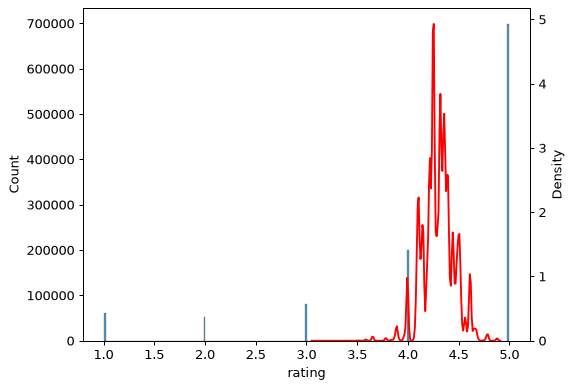

In [48]:
fig, ax1 = plt.subplots(dpi=90)
sns.histplot(y, kde=False, ax=ax1)

ax2 = ax1.twinx()  # separate scale for the KDE (density vs. count)
sns.kdeplot(X_train['brand_name'], color='r', ax=ax2)

plt.show()